In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import pandas as pd
import muon as mu

np.random.seed(42)
import random
random.seed(42)

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
import os
os.environ["SCIPY_ARRAY_API"] = "1"
from imblearn.over_sampling import RandomOverSampler

torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

torch.cuda.is_available()

True

In [3]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

# Import VAE models from functions module
import sys
sys.path.append('functions')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [5]:
import importlib
import functions.vae_models
# Now python knows what 'functions' is
importlib.reload(functions.vae_models)
from functions.vae_models import MultiModalConditionalVAE, SingleModalConditionalVAE

In [6]:
data_folder = 'raw_data/'

In [7]:
# Load CSV files
tcr_embs = pd.read_csv(data_folder + "tcr_embs.csv", index_col=0)
gex_df = pd.read_csv(data_folder + "gex_df.csv", index_col=0)
labels = pd.read_csv(data_folder + "labels.csv", index_col=0)

print(f"TCR embeddings shape: {tcr_embs.shape}")
print(f"Gene expression shape: {gex_df.shape}")
print(f"Labels shape: {labels.shape}")
print(f"\nTissue classes: {labels['label_tissue'].unique()}")
print(f"Sample IDs: {labels['label_sample_id'].nunique()} unique samples")


TCR embeddings shape: (40484, 1381)
Gene expression shape: (40484, 2995)
Labels shape: (40484, 10)

Tissue classes: ['CNS' 'Spleen' 'iLN' nan 'mLN' 'SI' 'DLN' 'MLN' 'PP' 'COL']
Sample IDs: 19 unique samples


## Label process

In [8]:
# Prepare data
# Filter out rows with NaN tissue labels
valid_mask = labels['label_tissue'].notna()
print(f"Rows with valid tissue labels: {valid_mask.sum()} / {len(labels)}")

# Filter data
tcr_embs_filtered = tcr_embs.loc[valid_mask]
gex_df_filtered = gex_df.loc[valid_mask]
labels_filtered = labels.loc[valid_mask]
common_idx_filtered = labels_filtered.index

# Convert tissue labels to 3 classes: 'CNS', 'Spleen', and 'else'
def convert_tissue_label(tissue):
    if pd.isna(tissue):
        return 'else'
    tissue_str = str(tissue).strip()
    if tissue_str == 'CNS':
        return 'CNS'
    elif tissue_str == 'Spleen':
        return 'Spleen'
    else:
        return 'else'

labels_filtered = labels_filtered.copy()
labels_filtered['label_tissue_converted'] = labels_filtered['label_tissue'].apply(convert_tissue_label)

print(f"\nTissue label distribution after conversion:")
print(labels_filtered['label_tissue_converted'].value_counts())



Rows with valid tissue labels: 38610 / 40484

Tissue label distribution after conversion:
label_tissue_converted
Spleen    26537
CNS        8541
else       3532
Name: count, dtype: int64


In [9]:
labels_filtered.head(5)

,label_tissue,label_cell_type,label_state,label_GSE,label_sample_id,label_CV_score_0,label_CV_score_1,label_CV_score_2,label_set,label_clone_id_size,label_tissue_converted
AAGTAGCAGATAGGCG-1_0516_CNS,CNS,CD4,Activation,LEE,5_7,0.049247,1.154527,0.485142,train,1.0,CNS
AAGTATACACCCAGTA-1_0516_CNS,CNS,NaN,Activation,LEE,5_7,-0.172905,-1.429184,-0.273997,train,1.0,CNS
AAGTTTGGTGGAACCC-1_0516_CNS,CNS,NaN,Exhaust,LEE,5_3,0.010912,0.491048,-0.117987,train,1.0,CNS
AATTCGCCAGCTGTAT-1_0516_CNS,CNS,Treg,Activation,LEE,5_6,-0.074756,-0.415768,0.490410,train,1.0,CNS
AGCAAGTAGAAATTGG-1_0516_CNS,CNS,Treg,Exhaust,LEE,5_3,-0.230434,0.223790,1.063392,train,1.0,CNS


## Select Features and Target Label

In [10]:
target_label = 'label_tissue_converted'
sample_label = 'label_GSE'

In [11]:
# Encode sample id labels as one-hot
sample_id_encoder = LabelEncoder()
std_scaler = StandardScaler()
sample_id_encoded = sample_id_encoder.fit_transform(labels_filtered[sample_label])
n_targer_class = len(sample_id_encoder.classes_)
sample_id_onehot = np.eye(n_targer_class)[sample_id_encoded]

# Add numeric values in labels_filtered as features
numeric_features = labels_filtered[['label_clone_id_size']].values.astype(float)
# 'label_CV_score_0', 'label_CV_score_1','label_CV_score_2'
numeric_features = std_scaler.fit_transform(numeric_features)

# Concatenate sample_id_onehot with clone_id_size to create condition features
sample_id_onehot = np.hstack([numeric_features, sample_id_onehot])


# Encode target labels
label_target = labels_filtered[target_label]
tissue_encoder = LabelEncoder()
tissue_labels = tissue_encoder.fit_transform(label_target)
n_tissues = len(tissue_encoder.classes_)

# Normalize features

tcr_data = std_scaler.fit_transform(tcr_embs_filtered.values)
gex_data = std_scaler.fit_transform(gex_df_filtered.values)

print(f"\nTCR data shape: {tcr_data.shape}")
print(f"GEX data shape: {gex_data.shape}")
print(f"Sample ID one-hot shape: {sample_id_onehot.shape}")
print(f"Number of tissue classes: {n_tissues}")
print(f"Tissue classes: {tissue_encoder.classes_}")
print(f"\nLabel set distribution:")
print(labels_filtered['label_set'].value_counts())



TCR data shape: (38610, 1381)
GEX data shape: (38610, 2995)
Sample ID one-hot shape: (38610, 6)
Number of tissue classes: 3
Tissue classes: ['CNS' 'Spleen' 'else']

Label set distribution:
label_set
train    33078
test      5532
Name: count, dtype: int64


## Train-Test Split

In [12]:
# Split data: use label_set to separate train and test
# Exclude label_set=='test' from training, use only for final evaluation
# CRITICAL: Ensure both train and test sets have all classes

train_mask = labels_filtered['label_set'] != 'test'
test_mask = labels_filtered['label_set'] == 'test'

train_idx = np.where(train_mask)[0]
test_idx = np.where(test_mask)[0]

print(f"Initial split - Train size (label_set != 'test'): {len(train_idx)}")
print(f"Initial split - Test size (label_set == 'test'): {len(test_idx)}")

# Check which classes are present in test set
test_classes = np.unique(tissue_labels[test_idx]) if len(test_idx) > 0 else np.array([])
all_classes = np.arange(n_tissues)
missing_classes = np.setdiff1d(all_classes, test_classes)

print(f"\nClasses in test set: {[tissue_encoder.inverse_transform([c])[0] for c in test_classes]}")
print(f"Missing classes in test set: {[tissue_encoder.inverse_transform([c])[0] for c in missing_classes]}")

# If test set is missing some classes, move samples from train to test
if len(missing_classes) > 0 and len(test_idx) > 0:
    print(f"\nMoving samples from train to test to ensure all classes are present...")
    samples_to_move = []
    
    for missing_class in missing_classes:
        # Find samples of this class in train set
        train_class_mask = tissue_labels[train_idx] == missing_class
        train_class_indices = train_idx[train_class_mask]
        
        if len(train_class_indices) > 0:
            # Move a small percentage (e.g., 5-10%) of this class to test
            n_to_move = max(1, min(10, len(train_class_indices) // 10))
            np.random.seed(42)
            selected = np.random.choice(train_class_indices, size=n_to_move, replace=False)
            samples_to_move.extend(selected)
            print(f"  Moving {n_to_move} samples of class '{tissue_encoder.inverse_transform([missing_class])[0]}' to test")
    
    if len(samples_to_move) > 0:
        samples_to_move = np.array(samples_to_move)
        # Update indices
        train_idx = np.setdiff1d(train_idx, samples_to_move)
        test_idx = np.concatenate([test_idx, samples_to_move])
        print(f"  Moved {len(samples_to_move)} samples total")

elif len(test_idx) == 0:
    # If no test set, split from train data with stratification
    print("Warning: No rows with label_set=='test' found. Splitting train data instead.")
    train_idx, test_idx = train_test_split(
        train_idx,
        test_size=0.2,
        random_state=42,
        stratify=tissue_labels[train_idx]
    )

# Final check: ensure both sets have all classes
train_classes = np.unique(tissue_labels[train_idx])
test_classes = np.unique(tissue_labels[test_idx])

print(f"\nFinal class check:")
print(f"  Train classes: {[tissue_encoder.inverse_transform([c])[0] for c in train_classes]}")
print(f"  Test classes: {[tissue_encoder.inverse_transform([c])[0] for c in test_classes]}")

if len(train_classes) < n_tissues or len(test_classes) < n_tissues:
    print("WARNING: Not all classes are present in both sets!")
    print("This may cause issues with classification_report. Consider adjusting the split.")

# Create final splits
tcr_train, tcr_test = tcr_data[train_idx], tcr_data[test_idx]
gex_train, gex_test = gex_data[train_idx], gex_data[test_idx]
sample_id_train, sample_id_test = sample_id_onehot[train_idx], sample_id_onehot[test_idx]
tissue_train, tissue_test = tissue_labels[train_idx], tissue_labels[test_idx]

print(f"\nFinal train size: {len(train_idx)}, Test size: {len(test_idx)}")
print(f"Train tissue distribution:")
unique_train, counts_train = np.unique(tissue_train, return_counts=True)
for label_idx, count in zip(unique_train, counts_train):
    print(f"  {tissue_encoder.inverse_transform([label_idx])[0]}: {count}")
print(f"Test tissue distribution:")
unique_test, counts_test = np.unique(tissue_test, return_counts=True)
for label_idx, count in zip(unique_test, counts_test):
    print(f"  {tissue_encoder.inverse_transform([label_idx])[0]}: {count}")


Initial split - Train size (label_set != 'test'): 33078
Initial split - Test size (label_set == 'test'): 5532

Classes in test set: ['CNS', 'Spleen']
Missing classes in test set: ['else']

Moving samples from train to test to ensure all classes are present...
  Moving 10 samples of class 'else' to test
  Moved 10 samples total

Final class check:
  Train classes: ['CNS', 'Spleen', 'else']
  Test classes: ['CNS', 'Spleen', 'else']

Final train size: 33068, Test size: 5542
Train tissue distribution:
  CNS: 7262
  Spleen: 22284
  else: 3522
Test tissue distribution:
  CNS: 1279
  Spleen: 4253
  else: 10


In [ ]:
## Multi-modal Conditional VAE Model
# Model class is imported from functions/vae_models.py
# Initialize model
model = MultiModalConditionalVAE(
    tcr_dim=tcr_data.shape[1],
    gex_dim=gex_data.shape[1],
    cond_in_dim = sample_id_onehot.shape[1],
    condition_emb_dim=10,
    latent_dim=128,
    hidden_dim=512,
    n_classes=n_tissues
).to(device)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(model)


Model parameters: 5,257,845
MultiModalConditionalVAE(
  (encoder_tcr): Sequential(
    (0): Linear(in_features=1381, out_features=512, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): ReLU()
    (6): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.2, inplace=False)
  )
  (encoder_gex): Sequential(
    (0): Linear(in_features=2995, out_features=512, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): ReLU()
    (6): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.2, inplace=False)
  )
  (encoder_condition): Sequential(
    (0): Linear

In [21]:
# Loss functions
def vae_loss(tcr_recon, tcr_true, gex_recon, gex_true, mu, logvar, 
             tcr_weight=1.0, gex_weight=1.0, kl_weight=0.001):
    """VAE loss: reconstruction + KL divergence"""
    # Reconstruction losses (MSE)
    tcr_recon_loss = F.mse_loss(tcr_recon, tcr_true, reduction='mean')
    gex_recon_loss = F.mse_loss(gex_recon, gex_true, reduction='mean')
    
    # KL divergence
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1).mean()
    
    total_loss = (tcr_weight * tcr_recon_loss + 
                  gex_weight * gex_recon_loss + 
                  kl_weight * kl_loss)
    
    return total_loss, tcr_recon_loss, gex_recon_loss, kl_loss

def classification_loss(pred, target):
    """Cross-entropy loss for classification"""
    return F.cross_entropy(pred, target)


In [ ]:
# Create data loaders
batch_size = 64

train_dataset = TensorDataset(
    torch.FloatTensor(tcr_train),
    torch.FloatTensor(gex_train),
    torch.FloatTensor(sample_id_train),
    torch.LongTensor(tissue_train)
)

test_dataset = TensorDataset(
    torch.FloatTensor(tcr_test),
    torch.FloatTensor(gex_test),
    torch.FloatTensor(sample_id_test),
    torch.LongTensor(tissue_test)
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train batches: {len(train_loader)}, Test batches: {len(test_loader)}")


Train batches: 517, Test batches: 87


In [17]:
# Training setup
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10, verbose=True)

n_epochs = 20
vae_weight = 0.5
class_weight = 1  # Weight for classification loss

train_losses = []
test_losses = []
train_accs = []
test_accs = []


NameError: name 'model' is not defined

In [ ]:
# Training loop
best_test_acc = 0.0

for epoch in range(n_epochs):
    # Training
    model.train()
    train_loss = 0.0
    train_vae_loss = 0.0
    train_class_loss = 0.0
    train_correct = 0
    train_total = 0
    
    for tcr_batch, gex_batch, condition_batch, tissue_batch in train_loader:
        tcr_batch = tcr_batch.to(device)
        gex_batch = gex_batch.to(device)
        condition_batch = condition_batch.to(device)
        tissue_batch = tissue_batch.to(device)
        
        optimizer.zero_grad()
        
        # Forward pass
        tcr_recon, gex_recon, mu, logvar, z, tissue_pred = model(
            tcr_batch, gex_batch, condition_batch
        )
        
        # Losses
        vae_loss_val, tcr_recon_loss, gex_recon_loss, kl_loss = vae_loss(
            tcr_recon, tcr_batch, gex_recon, gex_batch, mu, logvar
        )
        class_loss_val = classification_loss(tissue_pred, tissue_batch)
        
        total_loss = vae_weight * vae_loss_val + class_weight * class_loss_val
        
        # Backward pass
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        # Metrics
        train_loss += total_loss.item()
        train_vae_loss += vae_loss_val.item()
        train_class_loss += class_loss_val.item()
        
        _, predicted = torch.max(tissue_pred.data, 1)
        train_total += tissue_batch.size(0)
        train_correct += (predicted == tissue_batch).sum().item()
    
    # Validation
    model.eval()
    test_loss = 0.0
    test_vae_loss = 0.0
    test_class_loss = 0.0
    test_correct = 0
    test_total = 0
    
    with torch.no_grad():
        for tcr_batch, gex_batch, condition_batch, tissue_batch in test_loader:
            tcr_batch = tcr_batch.to(device)
            gex_batch = gex_batch.to(device)
            condition_batch = condition_batch.to(device)
            tissue_batch = tissue_batch.to(device)
            
            tcr_recon, gex_recon, mu, logvar, z, tissue_pred = model(
                tcr_batch, gex_batch, condition_batch
            )
            
            vae_loss_val, _, _, _ = vae_loss(
                tcr_recon, tcr_batch, gex_recon, gex_batch, mu, logvar
            )
            class_loss_val = classification_loss(tissue_pred, tissue_batch)
            
            total_loss = vae_weight * vae_loss_val + class_weight * class_loss_val
            
            test_loss += total_loss.item()
            test_vae_loss += vae_loss_val.item()
            test_class_loss += class_loss_val.item()
            
            _, predicted = torch.max(tissue_pred.data, 1)
            test_total += tissue_batch.size(0)
            test_correct += (predicted == tissue_batch).sum().item()
    
    # Average metrics
    train_loss /= len(train_loader)
    train_vae_loss /= len(train_loader)
    train_class_loss /= len(train_loader)
    train_acc = 100 * train_correct / train_total
    
    test_loss /= len(test_loader)
    test_vae_loss /= len(test_loader)
    test_class_loss /= len(test_loader)
    test_acc = 100 * test_correct / test_total
    
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)
    
    scheduler.step(test_loss)
    
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{n_epochs}]")
        print(f"  Train Loss: {train_loss:.4f} (VAE: {train_vae_loss:.4f}, Class: {train_class_loss:.4f}) | Acc: {train_acc:.2f}%")
        print(f"  Test Loss: {test_loss:.4f} (VAE: {test_vae_loss:.4f}, Class: {test_class_loss:.4f}) | Acc: {test_acc:.2f}%")
    
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        torch.save(model.state_dict(), 'best_vae_model.pth')
        if (epoch + 1) % 10 == 0:
            print(f"  -> New best model saved! (Test Acc: {best_test_acc:.2f}%)")

print(f"\nTraining completed! Best test accuracy: {best_test_acc:.2f}%")


Epoch [1/20]
  Train Loss: 1.2566 (VAE: 2.1082, Class: 0.2025) | Acc: 93.22%
  Test Loss: 1.2906 (VAE: 2.1299, Class: 0.2257) | Acc: 93.36%
Epoch [10/20]
  Train Loss: 0.8747 (VAE: 1.7250, Class: 0.0122) | Acc: 99.61%
  Test Loss: 1.3410 (VAE: 1.9387, Class: 0.3716) | Acc: 93.77%
Epoch [20/20]
  Train Loss: 0.8197 (VAE: 1.6304, Class: 0.0045) | Acc: 99.85%
  Test Loss: 1.3838 (VAE: 1.8615, Class: 0.4531) | Acc: 92.91%

Training completed! Best test accuracy: 94.28%


In [ ]:
# Save combined model results
combined_model_results = {
    'model_name': 'Combined (GEX + TCR)',
    'train_losses': train_losses.copy(),
    'test_losses': test_losses.copy(),
    'train_accs': train_accs.copy(),
    'test_accs': test_accs.copy(),
    'best_test_acc': best_test_acc
}
print(f"Combined model best test accuracy: {best_test_acc:.2f}%")


Combined model best test accuracy: 94.28%


In [ ]:
## Single-modality Conditional VAE Model
# Model class is imported from functions/vae_models.py


In [15]:
# Loss function for single-modality VAE
def single_modal_vae_loss(x_recon, x_true, mu, logvar, recon_weight=1.0, kl_weight=0.001):
    """VAE loss: reconstruction + KL divergence"""
    # Reconstruction loss (MSE)
    recon_loss = F.mse_loss(x_recon, x_true, reduction='mean')
    
    # KL divergence
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1).mean()
    
    total_loss = recon_weight * recon_loss + kl_weight * kl_loss
    
    return total_loss, recon_loss, kl_loss

def train_single_modal_model(model, train_loader, test_loader, model_name, n_epochs=40):
    """Train a single-modality model"""
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10, verbose=False)
    
    vae_weight = 1.0
    class_weight = 0.5
    
    train_losses = []
    test_losses = []
    train_accs = []
    test_accs = []
    best_test_acc = 0.0
    
    for epoch in range(n_epochs):
        # Training
        model.train()
        train_loss = 0.0
        train_vae_loss = 0.0
        train_class_loss = 0.0
        train_correct = 0
        train_total = 0
        
        for x_batch, condition_batch, tissue_batch in train_loader:
            x_batch = x_batch.to(device)
            condition_batch = condition_batch.to(device)
            tissue_batch = tissue_batch.to(device)
            
            optimizer.zero_grad()
            
            # Forward pass
            x_recon, mu, logvar, z, tissue_pred = model(x_batch, condition_batch)
            
            # Losses
            vae_loss_val, recon_loss, kl_loss = single_modal_vae_loss(
                x_recon, x_batch, mu, logvar
            )
            class_loss_val = classification_loss(tissue_pred, tissue_batch)
            
            total_loss = vae_weight * vae_loss_val + class_weight * class_loss_val
            
            # Backward pass
            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            # Metrics
            train_loss += total_loss.item()
            train_vae_loss += vae_loss_val.item()
            train_class_loss += class_loss_val.item()
            
            _, predicted = torch.max(tissue_pred.data, 1)
            train_total += tissue_batch.size(0)
            train_correct += (predicted == tissue_batch).sum().item()
        
        # Validation
        model.eval()
        test_loss = 0.0
        test_vae_loss = 0.0
        test_class_loss = 0.0
        test_correct = 0
        test_total = 0
        
        with torch.no_grad():
            for x_batch, condition_batch, tissue_batch in test_loader:
                x_batch = x_batch.to(device)
                condition_batch = condition_batch.to(device)
                tissue_batch = tissue_batch.to(device)
                
                x_recon, mu, logvar, z, tissue_pred = model(x_batch, condition_batch)
                
                vae_loss_val, _, _ = single_modal_vae_loss(
                    x_recon, x_batch, mu, logvar
                )
                class_loss_val = classification_loss(tissue_pred, tissue_batch)
                
                total_loss = vae_weight * vae_loss_val + class_weight * class_loss_val
                
                test_loss += total_loss.item()
                test_vae_loss += vae_loss_val.item()
                test_class_loss += class_loss_val.item()
                
                _, predicted = torch.max(tissue_pred.data, 1)
                test_total += tissue_batch.size(0)
                test_correct += (predicted == tissue_batch).sum().item()
        
        # Average metrics
        train_loss /= len(train_loader)
        train_vae_loss /= len(train_loader)
        train_class_loss /= len(train_loader)
        train_acc = 100 * train_correct / train_total
        
        test_loss /= len(test_loader)
        test_vae_loss /= len(test_loader)
        test_class_loss /= len(test_loader)
        test_acc = 100 * test_correct / test_total
        
        train_losses.append(train_loss)
        test_losses.append(test_loss)
        train_accs.append(train_acc)
        test_accs.append(test_acc)
        
        scheduler.step(test_loss)
        
        if (epoch + 1) % 20 == 0 or epoch == 0:
            print(f"{model_name} - Epoch [{epoch+1}/{n_epochs}]")
            print(f"  Train Loss: {train_loss:.4f} (VAE: {train_vae_loss:.4f}, Class: {train_class_loss:.4f}) | Acc: {train_acc:.2f}%")
            print(f"  Test Loss: {test_loss:.4f} (VAE: {test_vae_loss:.4f}, Class: {test_class_loss:.4f}) | Acc: {test_acc:.2f}%")
        
        if test_acc > best_test_acc:
            best_test_acc = test_acc
    
    print(f"{model_name} - Training completed! Best test accuracy: {best_test_acc:.2f}%\n")
    
    return {
        'model_name': model_name,
        'train_losses': train_losses,
        'test_losses': test_losses,
        'train_accs': train_accs,
        'test_accs': test_accs,
        'best_test_acc': best_test_acc,
        'model': model
    }


In [22]:
# Train GEX-only model
print("=" * 60)
print("Training GEX-only model")
print("=" * 60)
batch_size = 64
n_epochs = 20
vae_weight = 0.5
class_weight = 1  # Weight for classification loss

gex_train_dataset = TensorDataset(
    torch.FloatTensor(gex_train),
    torch.FloatTensor(sample_id_train),
    torch.LongTensor(tissue_train)
)

gex_test_dataset = TensorDataset(
    torch.FloatTensor(gex_test),
    torch.FloatTensor(sample_id_test),
    torch.LongTensor(tissue_test)
)

gex_train_loader = DataLoader(gex_train_dataset, batch_size=batch_size, shuffle=True)
gex_test_loader = DataLoader(gex_test_dataset, batch_size=batch_size, shuffle=False)

gex_model = SingleModalConditionalVAE(
    input_dim=gex_data.shape[1],
    cond_in_dim=sample_id_onehot.shape[1],
    condition_emb_dim=10,
    latent_dim=128,
    hidden_dim=512,
    n_classes=n_tissues
).to(device)

gex_results = train_single_modal_model(
    gex_model, gex_train_loader, gex_test_loader, 
    "GEX-only", n_epochs=n_epochs
)



Training GEX-only model
GEX-only - Epoch [1/20]
  Train Loss: 1.0063 (VAE: 0.9470, Class: 0.1186) | Acc: 95.92%
  Test Loss: 1.4831 (VAE: 1.3659, Class: 0.2343) | Acc: 94.75%
GEX-only - Epoch [20/20]
  Train Loss: 0.8534 (VAE: 0.8512, Class: 0.0044) | Acc: 99.87%
  Test Loss: 1.5867 (VAE: 1.4262, Class: 0.3211) | Acc: 94.51%
GEX-only - Training completed! Best test accuracy: 95.80%



In [23]:
# Train TCR-only model
print("=" * 60)
print("Training TCR-only model")
print("=" * 60)

tcr_train_dataset = TensorDataset(
    torch.FloatTensor(tcr_train),
    torch.FloatTensor(sample_id_train),
    torch.LongTensor(tissue_train)
)

tcr_test_dataset = TensorDataset(
    torch.FloatTensor(tcr_test),
    torch.FloatTensor(sample_id_test),
    torch.LongTensor(tissue_test)
)

tcr_train_loader = DataLoader(tcr_train_dataset, batch_size=batch_size, shuffle=True)
tcr_test_loader = DataLoader(tcr_test_dataset, batch_size=batch_size, shuffle=False)

tcr_model = SingleModalConditionalVAE(
    input_dim=tcr_data.shape[1],
    cond_in_dim=sample_id_onehot.shape[1],
    condition_emb_dim=10,
    latent_dim=128,
    hidden_dim=512,
    n_classes=n_tissues
).to(device)

tcr_results = train_single_modal_model(
    tcr_model, tcr_train_loader, tcr_test_loader, 
    "TCR-only", n_epochs=n_epochs
)


Training TCR-only model
TCR-only - Epoch [1/20]
  Train Loss: 1.1110 (VAE: 0.9108, Class: 0.4003) | Acc: 86.80%
  Test Loss: 1.8485 (VAE: 0.6705, Class: 2.3560) | Acc: 25.75%
TCR-only - Epoch [20/20]
  Train Loss: 0.5896 (VAE: 0.5400, Class: 0.0992) | Acc: 96.21%
  Test Loss: 2.7475 (VAE: 1.6911, Class: 2.1127) | Acc: 24.79%
TCR-only - Training completed! Best test accuracy: 47.91%



In [24]:
# Compare all three models
print("=" * 60)
print("MODEL COMPARISON SUMMARY")
print("=" * 60)
print(f"{'Model':<20} {'Best Test Accuracy':<20} {'Final Train Acc':<20} {'Final Test Acc':<20}")
print("-" * 80)
print(f"{combined_model_results['model_name']:<20} {combined_model_results['best_test_acc']:>18.2f}% {combined_model_results['train_accs'][-1]:>18.2f}% {combined_model_results['test_accs'][-1]:>18.2f}%")
print(f"{gex_results['model_name']:<20} {gex_results['best_test_acc']:>18.2f}% {gex_results['train_accs'][-1]:>18.2f}% {gex_results['test_accs'][-1]:>18.2f}%")
print(f"{tcr_results['model_name']:<20} {tcr_results['best_test_acc']:>18.2f}% {tcr_results['train_accs'][-1]:>18.2f}% {tcr_results['test_accs'][-1]:>18.2f}%")
print("=" * 60)


MODEL COMPARISON SUMMARY
Model                Best Test Accuracy   Final Train Acc      Final Test Acc      
--------------------------------------------------------------------------------


NameError: name 'combined_model_results' is not defined

In [ ]:
## Evaluation Function
def evaluate_model(model, test_loader, model_name):
    """Evaluate model and return predictions with proper label handling"""
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        if isinstance(model, MultiModalConditionalVAE):
            # Combined model
            for tcr_batch, gex_batch, condition_batch, tissue_batch in test_loader:
                tcr_batch = tcr_batch.to(device)
                gex_batch = gex_batch.to(device)
                condition_batch = condition_batch.to(device)
                _, _, _, _, _, tissue_pred = model(tcr_batch, gex_batch, condition_batch)
                _, predicted = torch.max(tissue_pred, 1)
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(tissue_batch.numpy())
        else:
            # Single modality model
            for x_batch, condition_batch, tissue_batch in test_loader:
                x_batch = x_batch.to(device)
                condition_batch = condition_batch.to(device)
                _, _, _, _, tissue_pred = model(x_batch, condition_batch)
                _, predicted = torch.max(tissue_pred, 1)
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(tissue_batch.numpy())
    
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    # Get all possible class labels (0 to n_classes-1)
    all_possible_labels = np.arange(len(tissue_encoder.classes_))
    class_names = [str(name) for name in tissue_encoder.classes_]
    accuracy = accuracy_score(all_labels, all_preds)
    
    print(f"\n{model_name} - Classification Report:")
    # Specify labels parameter to ensure all classes are included even if not present in test set
    print(classification_report(all_labels, all_preds, 
                              labels=all_possible_labels,
                              target_names=class_names,
                              zero_division=0))
    print(f"{model_name} - Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    
    return all_preds, all_labels, accuracy


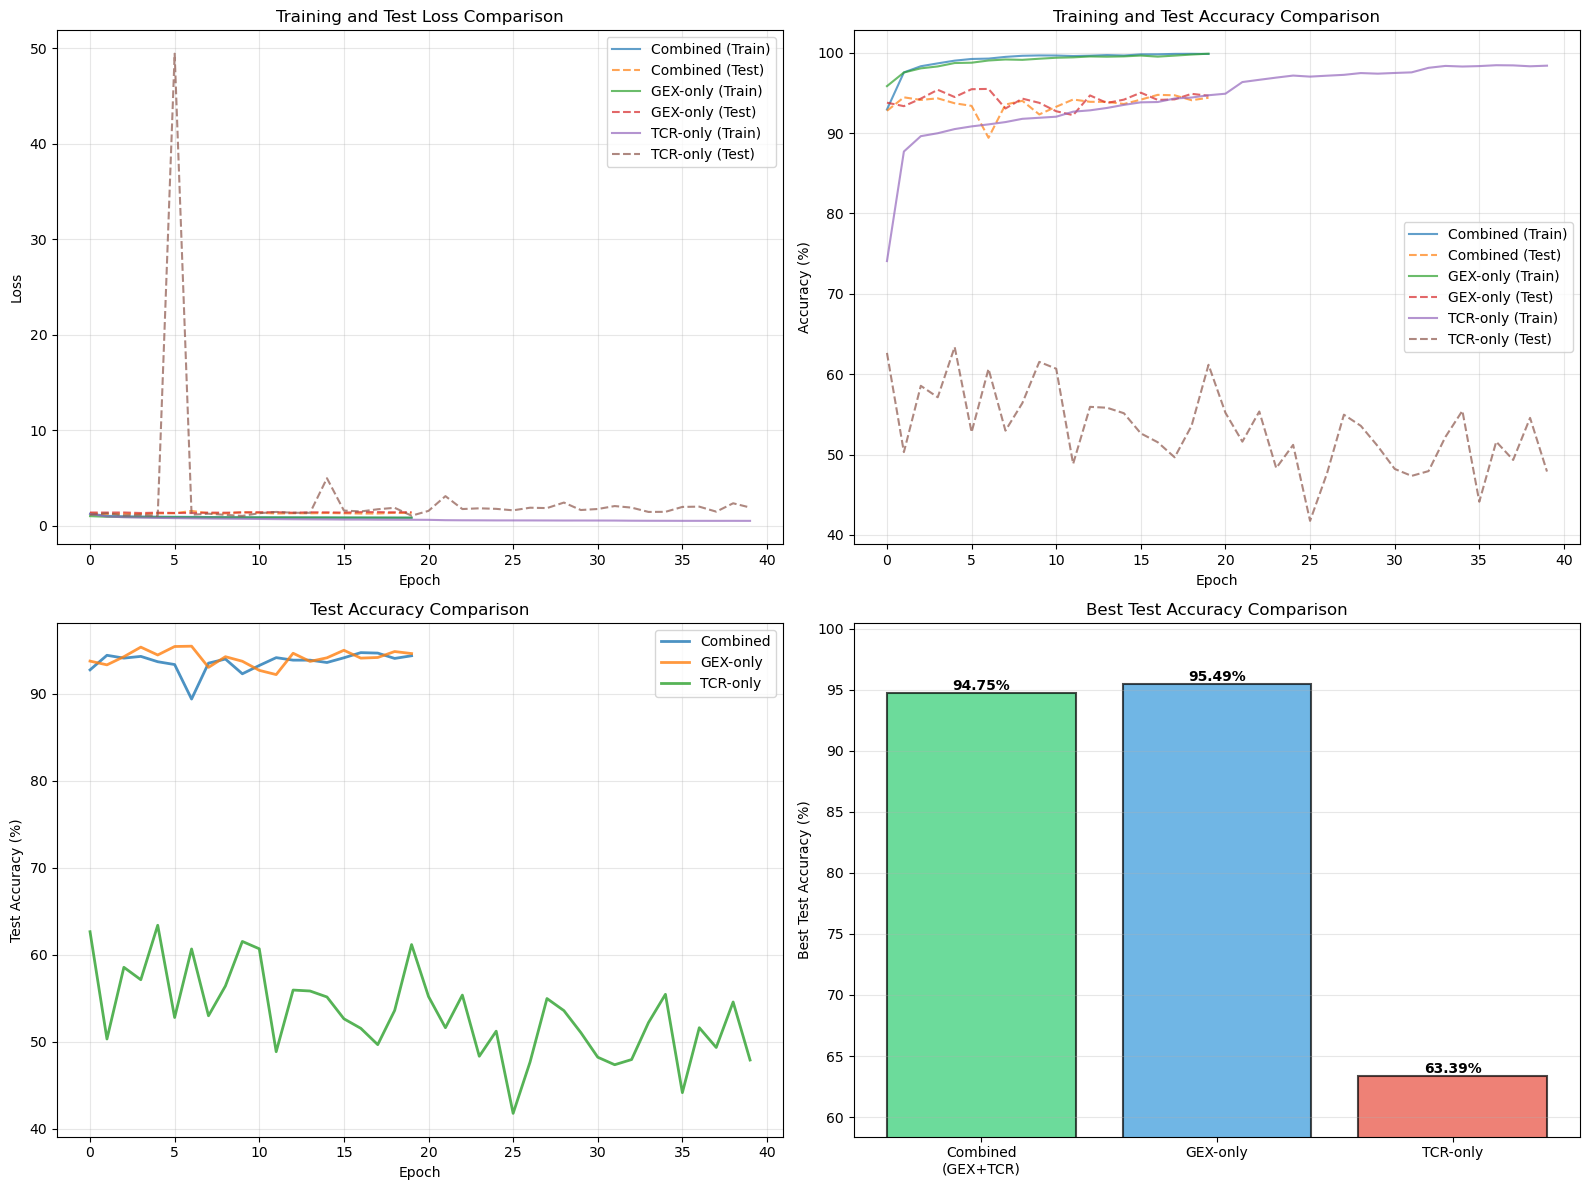

In [ ]:
# Plot comparison of all three models
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Loss comparison
axes[0, 0].plot(combined_model_results['train_losses'], label='Combined (Train)', alpha=0.7, linestyle='-')
axes[0, 0].plot(combined_model_results['test_losses'], label='Combined (Test)', alpha=0.7, linestyle='--')
axes[0, 0].plot(gex_results['train_losses'], label='GEX-only (Train)', alpha=0.7, linestyle='-')
axes[0, 0].plot(gex_results['test_losses'], label='GEX-only (Test)', alpha=0.7, linestyle='--')
axes[0, 0].plot(tcr_results['train_losses'], label='TCR-only (Train)', alpha=0.7, linestyle='-')
axes[0, 0].plot(tcr_results['test_losses'], label='TCR-only (Test)', alpha=0.7, linestyle='--')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training and Test Loss Comparison')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Accuracy comparison
axes[0, 1].plot(combined_model_results['train_accs'], label='Combined (Train)', alpha=0.7, linestyle='-')
axes[0, 1].plot(combined_model_results['test_accs'], label='Combined (Test)', alpha=0.7, linestyle='--')
axes[0, 1].plot(gex_results['train_accs'], label='GEX-only (Train)', alpha=0.7, linestyle='-')
axes[0, 1].plot(gex_results['test_accs'], label='GEX-only (Test)', alpha=0.7, linestyle='--')
axes[0, 1].plot(tcr_results['train_accs'], label='TCR-only (Train)', alpha=0.7, linestyle='-')
axes[0, 1].plot(tcr_results['test_accs'], label='TCR-only (Test)', alpha=0.7, linestyle='--')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].set_title('Training and Test Accuracy Comparison')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Test accuracy comparison (zoomed)
axes[1, 0].plot(combined_model_results['test_accs'], label='Combined', alpha=0.8, linewidth=2)
axes[1, 0].plot(gex_results['test_accs'], label='GEX-only', alpha=0.8, linewidth=2)
axes[1, 0].plot(tcr_results['test_accs'], label='TCR-only', alpha=0.8, linewidth=2)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Test Accuracy (%)')
axes[1, 0].set_title('Test Accuracy Comparison')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Bar chart of best test accuracies
models = ['Combined\n(GEX+TCR)', 'GEX-only', 'TCR-only']
best_accs = [
    combined_model_results['best_test_acc'],
    gex_results['best_test_acc'],
    tcr_results['best_test_acc']
]
colors = ['#2ecc71', '#3498db', '#e74c3c']
bars = axes[1, 1].bar(models, best_accs, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
axes[1, 1].set_ylabel('Best Test Accuracy (%)')
axes[1, 1].set_title('Best Test Accuracy Comparison')
axes[1, 1].set_ylim([min(best_accs) - 5, max(best_accs) + 5])
axes[1, 1].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, acc in zip(bars, best_accs):
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height,
                    f'{acc:.2f}%',
                    ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


In [ ]:
## Detailed Evaluation
# Evaluate all models
print("=" * 60)
print("DETAILED EVALUATION")
print("=" * 60)

# Load best combined model
model.load_state_dict(torch.load('best_vae_model.pth'))

combined_preds, combined_labels, combined_acc = evaluate_model(model, test_loader, "Combined")
gex_preds, gex_labels, gex_acc = evaluate_model(gex_model, gex_test_loader, "GEX-only")
tcr_preds, tcr_labels, tcr_acc = evaluate_model(tcr_model, tcr_test_loader, "TCR-only")


DETAILED EVALUATION

Combined - Classification Report:
              precision    recall  f1-score   support

         CNS       0.96      0.80      0.88      1279
      Spleen       0.94      0.99      0.97      4253
        else       0.69      0.90      0.78        10

    accuracy                           0.95      5542
   macro avg       0.87      0.90      0.88      5542
weighted avg       0.95      0.95      0.95      5542

Combined - Test Accuracy: 0.9471 (94.71%)

GEX-only - Classification Report:
              precision    recall  f1-score   support

         CNS       0.95      0.81      0.87      1279
      Spleen       0.94      0.99      0.97      4253
        else       0.89      0.80      0.84        10

    accuracy                           0.95      5542
   macro avg       0.93      0.87      0.89      5542
weighted avg       0.95      0.95      0.94      5542

GEX-only - Test Accuracy: 0.9451 (94.51%)

TCR-only - Classification Report:
              precision    re

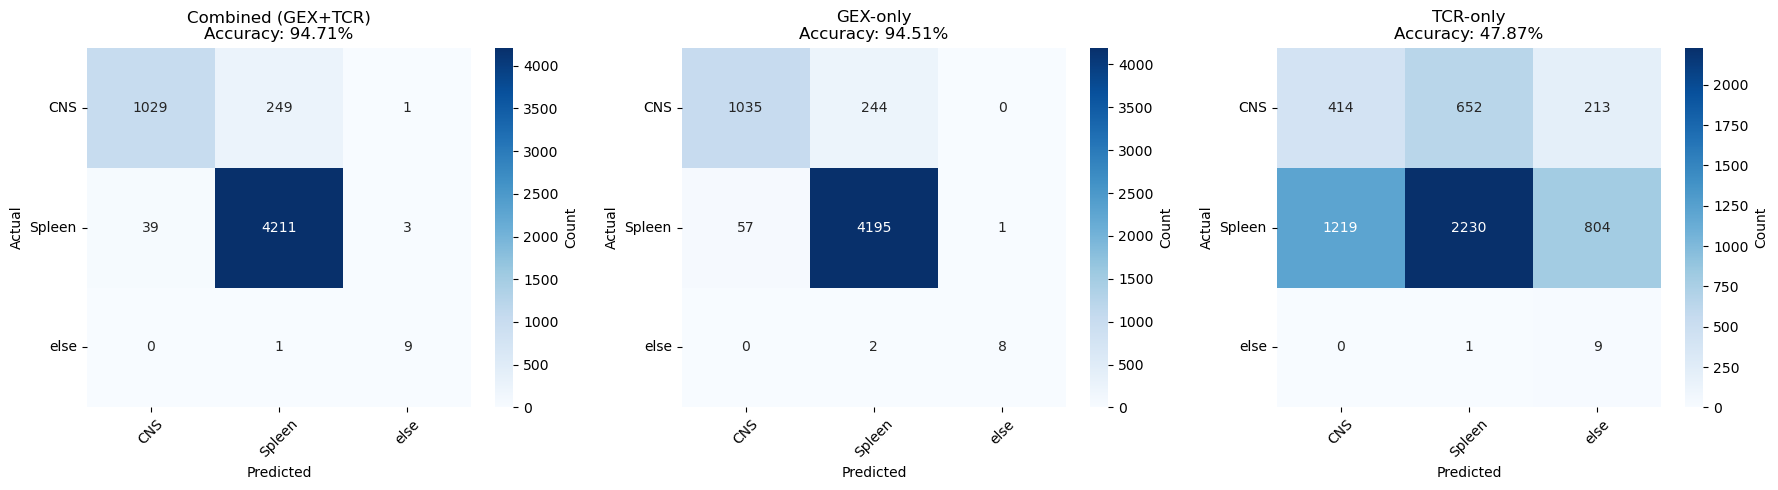

In [ ]:
# Confusion matrices comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
class_names = [str(name) for name in tissue_encoder.classes_]

models_data = [
    (combined_preds, combined_labels, "Combined (GEX+TCR)"),
    (gex_preds, gex_labels, "GEX-only"),
    (tcr_preds, tcr_labels, "TCR-only")
]

for idx, (preds, labels, title) in enumerate(models_data):
    cm = confusion_matrix(labels, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[idx], cbar_kws={'label': 'Count'})
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')
    axes[idx].set_title(f'{title}\nAccuracy: {accuracy_score(labels, preds)*100:.2f}%')
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()


In [ ]:
## Save Predictions
# Create predictions dataframe and save
predictions_df = pd.DataFrame({
    'combined_pred': combined_preds,
    'gex_pred': gex_preds,
    'tcr_pred': tcr_preds,
    'true_label': combined_labels
}, index=labels_filtered.index[test_idx])

predictions_df.to_csv('tissue_predictions_vae.csv', index=True)
print("Predictions saved to 'tissue_predictions_vae.csv'")


Predictions saved to 'tissue_predictions_vae.csv'


In [ ]:
## Save Models and Final Test Accuracies
# Create output directory if it doesn't exist
output_dir = output_cd
os.makedirs(output_dir, exist_ok=True)

# Save all trained models
print("Saving trained models...")
torch.save(model.state_dict(), os.path.join(output_dir, 'combined_model.pth'))
torch.save(gex_model.state_dict(), os.path.join(output_dir, 'gex_model.pth'))
torch.save(tcr_model.state_dict(), os.path.join(output_dir, 'tcr_model.pth'))
print("Models saved successfully!")

# Create dataframe with Final Test Accuracies
final_test_acc_df = pd.DataFrame({
    'Model': ['Combined (GEX+TCR)', 'GEX-only', 'TCR-only'],
    'Best_Test_Acc': [
        combined_model_results['best_test_acc'],
        gex_results['best_test_acc'],
        tcr_results['best_test_acc']
    ],
    'Final_Test_Acc': [
        combined_acc * 100,
        gex_acc * 100,
        tcr_acc * 100
    ]
})

# Save dataframe to CSV
acc_filepath = os.path.join(output_dir, 'final_test_accuracies.csv')
final_test_acc_df.to_csv(acc_filepath, index=False)
print(f"\nFinal Test Accuracies saved to '{acc_filepath}'")
print("\nFinal Test Accuracies:")
print(final_test_acc_df.to_string(index=False))


Saving trained models...
Models saved successfully!

Final Test Accuracies saved to 'raw_data\final_test_accuracies.csv'

Final Test Accuracies:
             Model  Best_Test_Acc  Final_Test_Acc
Combined (GEX+TCR)      94.749188       94.713100
          GEX-only      95.488993       94.514616
          TCR-only      63.388668       47.870805


In [ ]:
# Cell removed - was empty
